In [1]:
# ============================================================
# FRAUDLENS
# AI-BASED FINANCIAL TRANSACTION ANOMALY DETECTION
# Model: Isolation Forest
# Dataset: PaySim
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Enable inline plotting for charts
%matplotlib inline

# Display settings to avoid output and table truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("=" * 70)
print("FRAUDLENS - FINANCIAL TRANSACTION ANOMALY DETECTION")
print("=" * 70)



FRAUDLENS - FINANCIAL TRANSACTION ANOMALY DETECTION


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

FILE_PATH = "PS_20174392719_1491204439457_log.csv"

print("\nLoading dataset...")

start_load = time.time()

df = pd.read_csv(FILE_PATH)

load_time = time.time() - start_load

print(f"Dataset loaded in {load_time:.2f} seconds")
print("Original shape:", df.shape)




Loading dataset...
Dataset loaded in 6.08 seconds
Original shape: (6362620, 11)


In [3]:
# ============================================================
# 3. BASIC DATA UNDERSTANDING
# ============================================================

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())




DATASET INFORMATION

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0



Dataset shape:
(6362620, 11)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows:
0


In [4]:
# ============================================================
# 4. REMOVE TIME-RELATED COLUMN
# ============================================================

# PaySim contains a 'step' column representing time.
# We intentionally DO NOT use it.

if "step" in df.columns:
    df.drop(columns=["step"], inplace=True)

print("\nTime-related column removed: step")
print("Shape after removing time column:", df.shape)




Time-related column removed: step
Shape after removing time column: (6362620, 10)


In [5]:
# ============================================================
# 5. DATA CLEANING
# ============================================================

print("\n" + "=" * 70)
print("DATA CLEANING")
print("=" * 70)

# Remove duplicate rows
duplicates_before = df.duplicated().sum()

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Duplicates removed:", duplicates_before)

# Check invalid transaction amounts
invalid_amounts = (df["amount"] < 0).sum()

print("Invalid negative amounts:", invalid_amounts)

# Keep only positive transactions
df = df[df["amount"] > 0].copy()

print("Shape after cleaning:", df.shape)




DATA CLEANING
Duplicates removed: 0
Invalid negative amounts: 0
Shape after cleaning: (6362604, 10)


In [6]:
# ============================================================
# 6. UNDERSTAND TRANSACTION TYPES
# ============================================================

print("\nTransaction types:")

print(df["type"].value_counts())




Transaction types:
type
CASH_OUT    2237484
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [7]:
# ============================================================
# 7. FRAUD DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("ACTUAL FRAUD DISTRIBUTION")
print("=" * 70)

if "isFraud" in df.columns:

    fraud_counts = df["isFraud"].value_counts()

    print(fraud_counts)

    fraud_percentage = (
        df["isFraud"].mean() * 100
    )

    print(
        f"\nActual fraud percentage: "
        f"{fraud_percentage:.4f}%"
    )




ACTUAL FRAUD DISTRIBUTION
isFraud
0    6354407
1       8197
Name: count, dtype: int64

Actual fraud percentage: 0.1288%



EXPLORATORY DATA ANALYSIS


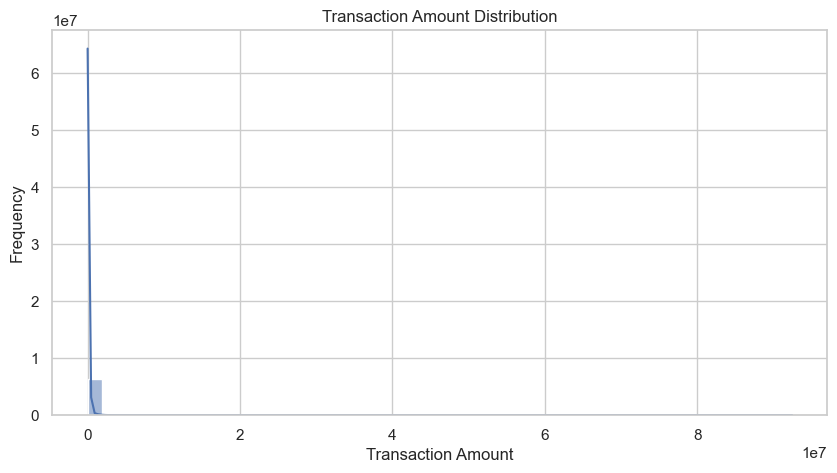

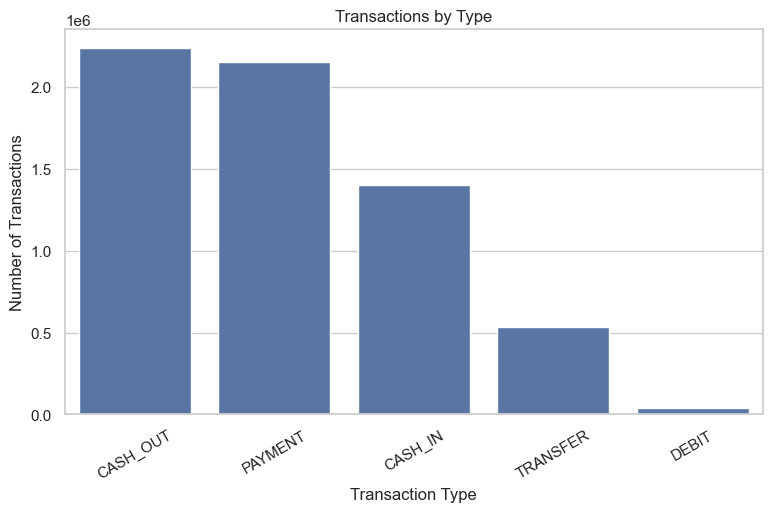

In [8]:
# ============================================================
# 8. EXPLORATORY DATA ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)


# Transaction amount distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    df["amount"],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()


# Transaction type distribution

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)

plt.show()



In [9]:
# ============================================================
# 9. FEATURE ENGINEERING
# ============================================================

print("\n" + "=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)


# ------------------------------------------------------------
# Origin account balance change
# ------------------------------------------------------------

df["origin_balance_change"] = (
    df["oldbalanceOrg"] -
    df["newbalanceOrig"]
)


# ------------------------------------------------------------
# Destination account balance change
# ------------------------------------------------------------

df["destination_balance_change"] = (
    df["newbalanceDest"] -
    df["oldbalanceDest"]
)


# ------------------------------------------------------------
# Amount to origin balance ratio
# ------------------------------------------------------------

df["amount_origin_ratio"] = (
    df["amount"] /
    (df["oldbalanceOrg"] + 1)
)


# ------------------------------------------------------------
# Amount to destination balance ratio
# ------------------------------------------------------------

df["amount_destination_ratio"] = (
    df["amount"] /
    (df["oldbalanceDest"] + 1)
)


# ------------------------------------------------------------
# Log transaction amount
# ------------------------------------------------------------

df["log_amount"] = np.log1p(
    df["amount"]
)


# ------------------------------------------------------------
# Balance inconsistency
# ------------------------------------------------------------

df["origin_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
).abs()


# ------------------------------------------------------------
# Destination balance inconsistency
# ------------------------------------------------------------

df["destination_balance_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
).abs()


print("\nNew features created:")

new_features = [
    "origin_balance_change",
    "destination_balance_change",
    "amount_origin_ratio",
    "amount_destination_ratio",
    "log_amount",
    "origin_balance_error",
    "destination_balance_error"
]

for feature in new_features:
    print(" -", feature)




FEATURE ENGINEERING

New features created:
 - origin_balance_change
 - destination_balance_change
 - amount_origin_ratio
 - amount_destination_ratio
 - log_amount
 - origin_balance_error
 - destination_balance_error


In [10]:
# ============================================================
# 10. CREATE MODEL DATA
# ============================================================

print("\n" + "=" * 70)
print("PREPARING MODEL DATA")
print("=" * 70)


# We intentionally do NOT use:
#
# step
# isFraud
# isFlaggedFraud
# nameOrig
# nameDest
#
# because:
# - step = time information
# - isFraud = target/evaluation label
# - isFlaggedFraud = existing fraud indicator
# - account names = identifiers rather than useful numeric behavior


model_features = [

    "amount",

    "oldbalanceOrg",
    "newbalanceOrig",

    "oldbalanceDest",
    "newbalanceDest",

    "origin_balance_change",
    "destination_balance_change",

    "amount_origin_ratio",
    "amount_destination_ratio",

    "log_amount",

    "origin_balance_error",
    "destination_balance_error"
]


X = df[model_features].copy()


# Replace infinity values

X.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)


# Replace missing values

X.fillna(0, inplace=True)


print("\nModel features:")

for feature in model_features:
    print(" -", feature)

print("\nFeature matrix shape:", X.shape)




PREPARING MODEL DATA

Model features:
 - amount
 - oldbalanceOrg
 - newbalanceOrig
 - oldbalanceDest
 - newbalanceDest
 - origin_balance_change
 - destination_balance_change
 - amount_origin_ratio
 - amount_destination_ratio
 - log_amount
 - origin_balance_error
 - destination_balance_error

Feature matrix shape: (6362604, 12)


In [11]:
# ============================================================
# 11. SAMPLE DATA FOR TRAINING
# ============================================================

# PaySim contains more than 6 million rows.
# Training the first version on the entire dataset is unnecessary.
#
# We use 300,000 rows for the project model.
#
# The sample is randomly selected and reproducible.

SAMPLE_SIZE = min(
    300_000,
    len(X)
)

sample_indices = np.random.RandomState(
    42
).choice(
    len(X),
    size=SAMPLE_SIZE,
    replace=False
)

X_sample = X.iloc[
    sample_indices
].copy()

df_sample = df.iloc[
    sample_indices
].copy()

print("\nTraining sample size:", X_sample.shape)




Training sample size: (300000, 12)


In [12]:
# ============================================================
# 12. TRAIN ISOLATION FOREST
# ============================================================

print("\n" + "=" * 70)
print("TRAINING ISOLATION FOREST")
print("=" * 70)

start_training = time.time()


model = IsolationForest(

    # Number of isolation trees
    n_estimators=150,

    # Initial expected anomaly proportion
    contamination=0.01,

    # Automatically determine samples per tree
    max_samples="auto",

    # Use all selected features
    max_features=1.0,

    # Reproducibility
    random_state=42,

    # Use all CPU cores
    n_jobs=-1
)


model.fit(X_sample)


training_time = (
    time.time() -
    start_training
)


print(
    f"\nTraining completed in "
    f"{training_time:.2f} seconds"
)




TRAINING ISOLATION FOREST

Training completed in 2.13 seconds


In [13]:
# ============================================================
# 13. PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("GENERATING ANOMALY PREDICTIONS")
print("=" * 70)


df_sample["IF_PREDICTION"] = (
    model.predict(X_sample)
)


# Isolation Forest:
#
#  1  = Normal
# -1  = Anomaly


df_sample["ANOMALY"] = (
    df_sample["IF_PREDICTION"]
    .map({
        1: 0,
        -1: 1
    })
)


# Human-readable status

df_sample["STATUS"] = (
    df_sample["ANOMALY"]
    .map({
        0: "Normal",
        1: "Flagged for Review"
    })
)




GENERATING ANOMALY PREDICTIONS


In [14]:
# ============================================================
# 14. ANOMALY SCORE
# ============================================================

df_sample["ANOMALY_SCORE"] = (
    model.decision_function(
        X_sample
    )
)


# Lower score = more anomalous



In [15]:
# ============================================================
# 15. ANOMALY SUMMARY
# ============================================================

total = len(df_sample)

normal_count = (
    df_sample["ANOMALY"] == 0
).sum()

anomaly_count = (
    df_sample["ANOMALY"] == 1
).sum()

anomaly_percentage = (
    anomaly_count /
    total
) * 100


print("\n" + "=" * 70)
print("ANOMALY DETECTION RESULTS")
print("=" * 70)

print(f"Total transactions : {total:,}")
print(f"Normal transactions: {normal_count:,}")
print(f"Flagged transactions: {anomaly_count:,}")
print(
    f"Detected anomaly percentage: "
    f"{anomaly_percentage:.2f}%"
)




ANOMALY DETECTION RESULTS
Total transactions : 300,000
Normal transactions: 297,000
Flagged transactions: 3,000
Detected anomaly percentage: 1.00%


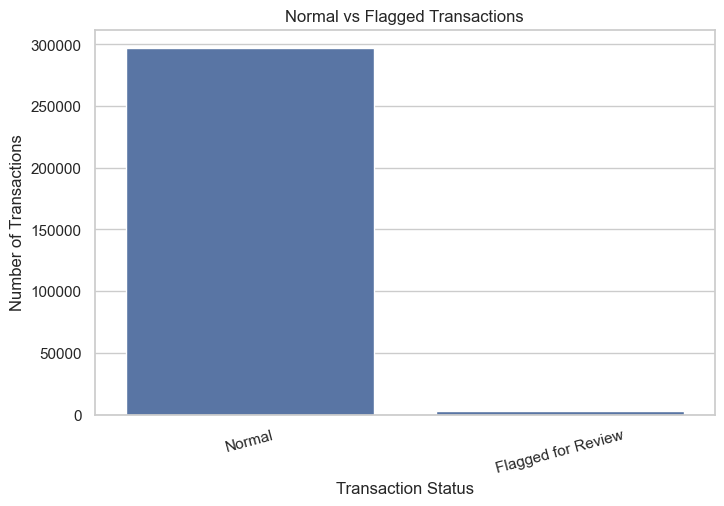

In [16]:
# ============================================================
# 16. NORMAL VS ANOMALY VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_sample,
    x="STATUS"
)

plt.title(
    "Normal vs Flagged Transactions"
)

plt.xlabel("Transaction Status")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=15)

plt.show()



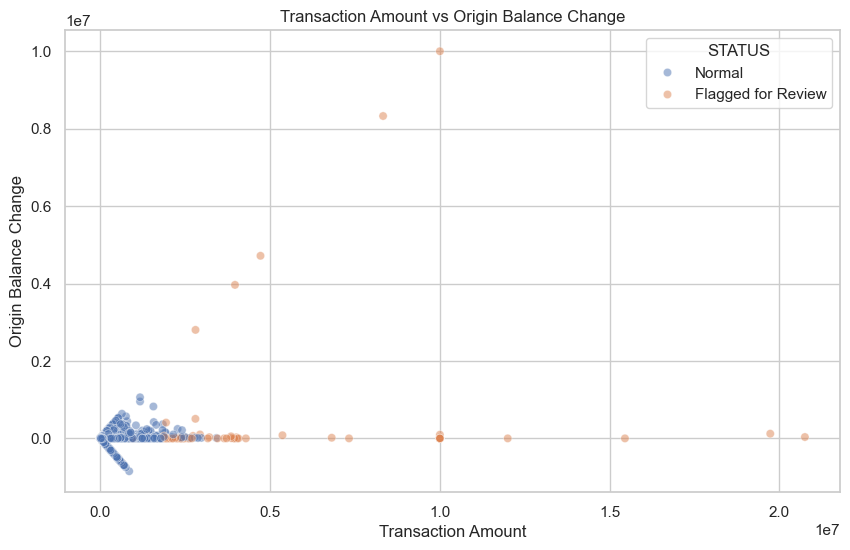

In [17]:
# ============================================================
# 17. AMOUNT VS BALANCE CHANGE
# ============================================================

plot_df = df_sample.sample(
    min(10000, len(df_sample)),
    random_state=42
)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x="amount",
    y="origin_balance_change",
    hue="STATUS",
    alpha=0.5
)

plt.title(
    "Transaction Amount vs Origin Balance Change"
)

plt.xlabel("Transaction Amount")

plt.ylabel(
    "Origin Balance Change"
)

plt.show()



In [18]:
# ============================================================
# 18. TOP SUSPICIOUS TRANSACTIONS
# ============================================================

print("\n" + "=" * 70)
print("TOP SUSPICIOUS TRANSACTIONS")
print("=" * 70)


top_suspicious = (
    df_sample
    .sort_values(
        "ANOMALY_SCORE",
        ascending=True
    )
    .head(20)
)


display(
    top_suspicious[
        [
            "nameOrig",
            "nameDest",
            "type",
            "amount",
            "oldbalanceOrg",
            "newbalanceOrig",
            "oldbalanceDest",
            "newbalanceDest",
            "ANOMALY_SCORE",
            "STATUS"
        ]
    ]
)




TOP SUSPICIOUS TRANSACTIONS


,nameOrig,nameDest,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,ANOMALY_SCORE,STATUS
3966471,C80571844,C310383504,TRANSFER,"15,822,130.17",0.00,0.00,"129,168,459.28","192,278,925.55",-0.19,Flagged for Review
4183292,C1518444935,C821676364,TRANSFER,"10,000,000.00",0.00,0.00,"30,132,859.50","51,919,045.75",-0.18,Flagged for Review
4180374,C1011847188,C1191573842,TRANSFER,"10,000,000.00",0.00,0.00,"50,087,396.39","72,491,028.06",-0.18,Flagged for Review
4179296,C1759277936,C2115397483,TRANSFER,"10,000,000.00",0.00,0.00,"30,044,656.98","47,662,108.83",-0.18,Flagged for Review
4171337,C166630777,C1732158567,TRANSFER,"10,000,000.00",0.00,0.00,"31,964,425.06","50,041,169.68",-0.18,Flagged for Review
4217641,C385490956,C1487890981,TRANSFER,"10,000,000.00",0.00,0.00,"30,200,815.46","47,070,380.59",-0.18,Flagged for Review
4212151,C785717109,C1928603721,TRANSFER,"10,000,000.00","509,757.00",0.00,0.00,"34,296,726.19",-0.18,Flagged for Review
4182149,C433764902,C82947915,TRANSFER,"10,000,000.00",0.00,0.00,"20,000,000.00","40,880,103.34",-0.18,Flagged for Review
4168153,C1368954627,C601303605,TRANSFER,"10,000,000.00",0.00,0.00,"20,000,000.00","41,752,611.51",-0.18,Flagged for Review
3892980,C1247182605,C1381840127,TRANSFER,"15,488,604.70",0.00,0.00,"48,862,801.64","67,758,193.06",-0.18,Flagged for Review



MODEL EVALUATION

IMPORTANT:
isFraud was NOT used during Isolation Forest training.
It is being used ONLY here as a ground-truth evaluation label.

Precision: 0.0307
Recall   : 0.2507
F1 Score : 0.0546

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    299633
       Fraud       0.03      0.25      0.05       367

    accuracy                           0.99    300000
   macro avg       0.51      0.62      0.52    300000
weighted avg       1.00      0.99      0.99    300000



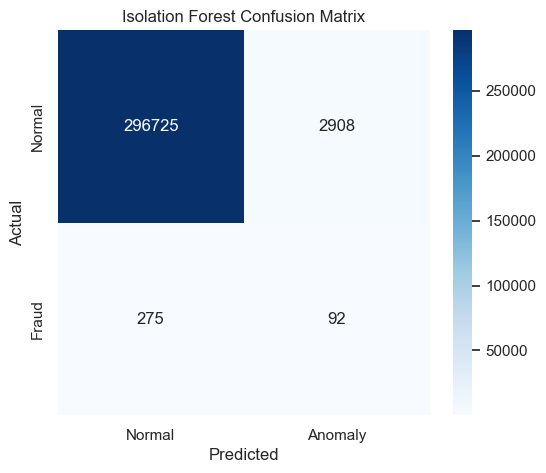

In [19]:
# ============================================================
# 19. EVALUATION USING isFraud
# ============================================================

print("\n" + "=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

print(
    """
IMPORTANT:
isFraud was NOT used during Isolation Forest training.
It is being used ONLY here as a ground-truth evaluation label.
"""
)


if "isFraud" in df_sample.columns:

    y_true = (
        df_sample["isFraud"]
    )

    y_pred = (
        df_sample["ANOMALY"]
    )


    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )


    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1 Score : {f1:.4f}"
    )


    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Normal",
                "Fraud"
            ],
            zero_division=0
        )
    )


    # Confusion Matrix

    cm = confusion_matrix(
        y_true,
        y_pred
    )


    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",

        xticklabels=[
            "Normal",
            "Anomaly"
        ],

        yticklabels=[
            "Normal",
            "Fraud"
        ]
    )

    plt.title(
        "Isolation Forest Confusion Matrix"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.show()



In [20]:
# ============================================================
# 20. ACTUAL FRAUD VS DETECTED ANOMALY
# ============================================================

if "isFraud" in df_sample.columns:

    actual_fraud = (
        df_sample["isFraud"].sum()
    )

    detected_anomaly = (
        df_sample["ANOMALY"].sum()
    )

    print("\nActual fraud transactions:",
          actual_fraud)

    print("Detected anomalies:",
          detected_anomaly)




Actual fraud transactions: 367
Detected anomalies: 3000


In [21]:
# ============================================================
# 21. SAVE FLAGGED TRANSACTIONS
# ============================================================

output_columns = [

    "nameOrig",
    "nameDest",
    "type",

    "amount",

    "oldbalanceOrg",
    "newbalanceOrig",

    "oldbalanceDest",
    "newbalanceDest",

    "origin_balance_change",
    "destination_balance_change",

    "amount_origin_ratio",
    "amount_destination_ratio",

    "ANOMALY_SCORE",

    "STATUS"
]


available_columns = [
    col
    for col in output_columns
    if col in df_sample.columns
]


flagged_transactions = (
    df_sample[
        df_sample["ANOMALY"] == 1
    ][available_columns]
    .sort_values(
        "ANOMALY_SCORE"
    )
)


flagged_transactions.to_csv(
    "flagged_transactions.csv",
    index=False
)


print(
    "\nFlagged transactions saved to:"
)

print(
    "flagged_transactions.csv"
)




Flagged transactions saved to:
flagged_transactions.csv


In [22]:
# ============================================================
# 22. NEW TRANSACTION PREDICTION
# ============================================================

print("\n" + "=" * 70)
print("NEW TRANSACTION ANOMALY PREDICTION")
print("=" * 70)


# Example transaction

new_transaction = pd.DataFrame({

    "amount": [250000],

    "oldbalanceOrg": [300000],

    "newbalanceOrig": [50000],

    "oldbalanceDest": [10000],

    "newbalanceDest": [260000]

})


# Feature engineering

new_transaction[
    "origin_balance_change"
] = (
    new_transaction["oldbalanceOrg"]
    -
    new_transaction["newbalanceOrig"]
)


new_transaction[
    "destination_balance_change"
] = (
    new_transaction["newbalanceDest"]
    -
    new_transaction["oldbalanceDest"]
)


new_transaction[
    "amount_origin_ratio"
] = (
    new_transaction["amount"]
    /
    (new_transaction["oldbalanceOrg"] + 1)
)


new_transaction[
    "amount_destination_ratio"
] = (
    new_transaction["amount"]
    /
    (new_transaction["oldbalanceDest"] + 1)
)


new_transaction[
    "log_amount"
] = np.log1p(
    new_transaction["amount"]
)


new_transaction[
    "origin_balance_error"
] = (
    new_transaction["oldbalanceOrg"]
    -
    new_transaction["amount"]
    -
    new_transaction["newbalanceOrig"]
).abs()


new_transaction[
    "destination_balance_error"
] = (
    new_transaction["oldbalanceDest"]
    +
    new_transaction["amount"]
    -
    new_transaction["newbalanceDest"]
).abs()


# Select model features

new_X = new_transaction[
    model_features
].copy()


new_X.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

new_X.fillna(0, inplace=True)


# Prediction

new_prediction = (
    model.predict(new_X)[0]
)


new_score = (
    model.decision_function(new_X)[0]
)


if new_prediction == -1:

    print(
        "⚠️ RESULT: FLAGGED FOR REVIEW"
    )

else:

    print(
        "✅ RESULT: NORMAL"
    )


print(
    f"Anomaly Score: {new_score:.6f}"
)




NEW TRANSACTION ANOMALY PREDICTION
✅ RESULT: NORMAL
Anomaly Score: 0.242219


In [23]:
# ============================================================
# 23. FINAL PROJECT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FRAUDLENS PROJECT SUMMARY")
print("=" * 70)

print("Project               : FraudLens")
print("Dataset               : PaySim")
print("Algorithm             : Isolation Forest")
print("Learning Type         : Unsupervised")
print("Time Column Used      : NO")
print("Training Sample       :", f"{SAMPLE_SIZE:,}")
print("Number of Features    :", len(model_features))
print(
    "Training Time         :",
    f"{training_time:.2f} seconds"
)

print("\nModel Features:")

for feature in model_features:
    print("  ✓", feature)

print("\nFinal Status:")
print("  ✓ Data cleaning completed")
print("  ✓ Feature engineering completed")
print("  ✓ EDA completed")
print("  ✓ Isolation Forest trained")
print("  ✓ Anomalies detected")
print("  ✓ Evaluation completed")
print("  ✓ Flagged transactions exported")

print("\nFraudLens pipeline completed successfully!")


FRAUDLENS PROJECT SUMMARY
Project               : FraudLens
Dataset               : PaySim
Algorithm             : Isolation Forest
Learning Type         : Unsupervised
Time Column Used      : NO
Training Sample       : 300,000
Number of Features    : 12
Training Time         : 2.13 seconds

Model Features:
  ✓ amount
  ✓ oldbalanceOrg
  ✓ newbalanceOrig
  ✓ oldbalanceDest
  ✓ newbalanceDest
  ✓ origin_balance_change
  ✓ destination_balance_change
  ✓ amount_origin_ratio
  ✓ amount_destination_ratio
  ✓ log_amount
  ✓ origin_balance_error
  ✓ destination_balance_error

Final Status:
  ✓ Data cleaning completed
  ✓ Feature engineering completed
  ✓ EDA completed
  ✓ Isolation Forest trained
  ✓ Anomalies detected
  ✓ Evaluation completed
  ✓ Flagged transactions exported

FraudLens pipeline completed successfully!
